In [1]:
!pip install scikit-learn imbalanced-learn matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the processed dataset
df = pd.read_csv("judgments_final.csv")

# Keep only labeled cases (exclude Unknown)
df_labeled = df[df['outcome'] != 'Unknown'].copy()
df_labeled = df_labeled[df_labeled['clean_text'].notna()].copy()
df_labeled = df_labeled[df_labeled['clean_text'].str.strip() != ''].copy()

print(f"Total cases loaded     : {len(df)}")
print(f"Labeled cases          : {len(df_labeled)}")
print(f"Outcome classes        : {df_labeled['outcome'].unique().tolist()}")
print(f"\nClass distribution:")
print(df_labeled['outcome'].value_counts())

Total cases loaded     : 26688
Labeled cases          : 22613
Outcome classes        : ['Allowed', 'Dismissed', 'Remanded', 'Partly Allowed']

Class distribution:
outcome
Dismissed         12334
Allowed            8732
Partly Allowed      889
Remanded            658
Name: count, dtype: int64


In [3]:
# Use last 40% of text (where judgment/order appears) + first 10% (facts)
# This gives better signal than using full text for TF-IDF
def get_key_sections(text, total_words=2000):
    words = str(text).split()
    n = len(words)
    # Take first 500 words (facts) + last 1500 words (order/judgment)
    head = words[:500]
    tail = words[max(0, n-1500):]
    return " ".join(head + tail)

df_labeled['model_text'] = df_labeled['clean_text'].apply(get_key_sections)

# Features and labels
X = df_labeled['model_text']
y = df_labeled['outcome']

# Train/test split (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples  : {len(X_train)}")
print(f"Test samples      : {len(X_test)}")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training samples  : 18090
Test samples      : 4523

Training class distribution:
outcome
Dismissed         9867
Allowed           6986
Partly Allowed     711
Remanded           526
Name: count, dtype: int64

Test class distribution:
outcome
Dismissed         2467
Allowed           1746
Partly Allowed     178
Remanded           132
Name: count, dtype: int64


In [4]:
# TF-IDF + Logistic Regression pipeline with class weighting
# class_weight='balanced' automatically handles the imbalance

baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),      # unigrams + bigrams
        sublinear_tf=True,       # log normalization
        min_df=3,                # ignore very rare terms
        max_df=0.95,             # ignore very common terms
        strip_accents='unicode',
        analyzer='word'
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced', # handles Dismissed/Allowed imbalance
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial',
        random_state=42
    ))
])

print("Training baseline model (TF-IDF + Logistic Regression)...")
baseline_model.fit(X_train, y_train)
print("✅ Training complete!")

# Evaluate
y_pred = baseline_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n── Accuracy: {acc*100:.2f}%")
print(f"\n── Classification Report ────────────────────────")
print(classification_report(y_test, y_pred))

Training baseline model (TF-IDF + Logistic Regression)...
✅ Training complete!

── Accuracy: 78.93%

── Classification Report ────────────────────────
                precision    recall  f1-score   support

       Allowed       0.76      0.79      0.78      1746
     Dismissed       0.86      0.82      0.84      2467
Partly Allowed       0.48      0.60      0.53       178
      Remanded       0.40      0.39      0.40       132

      accuracy                           0.79      4523
     macro avg       0.63      0.65      0.64      4523
  weighted avg       0.79      0.79      0.79      4523



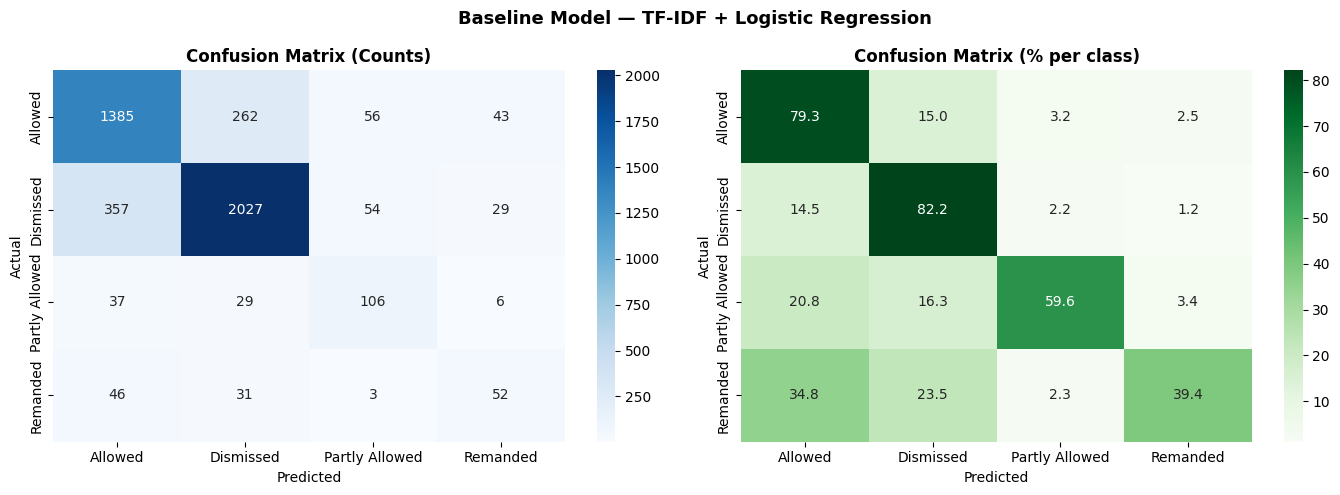

✅ Saved: confusion_matrix_baseline.png


In [5]:
labels = ['Allowed', 'Dismissed', 'Partly Allowed', 'Remanded']

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Percentage
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (% per class)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Baseline Model — TF-IDF + Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix_baseline.png")

In [6]:
def predict_outcome(text, model=baseline_model, verbose=True):
    """
    Pass any judgment text or case description.
    Returns predicted outcome and confidence scores.
    """
    # Prepare text same way as training
    processed = get_key_sections(text)

    # Predict
    prediction = model.predict([processed])[0]
    probabilities = model.predict_proba([processed])[0]
    classes = model.classes_

    # Sort by confidence
    prob_dict = dict(zip(classes, probabilities))
    prob_sorted = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True))

    if verbose:
        print("=" * 55)
        print("  ⚖️  CASE OUTCOME PREDICTION")
        print("=" * 55)
        print(f"\n  🔮 Predicted Outcome  :  {prediction}")
        print(f"\n  📊 Confidence Scores  :")
        for outcome, prob in prob_sorted.items():
            bar = "█" * int(prob * 30)
            marker = " ← predicted" if outcome == prediction else ""
            print(f"     {outcome:<16} {prob*100:5.1f}%  {bar}{marker}")
        print("=" * 55)

    return prediction, prob_sorted


# ── TEST 1: Paste a real snippet from your dataset ────────
sample_text = df_labeled['clean_text'].iloc[100]
#print("📄 Sample text (first 500 chars): "+sample_text)

print("📄 Testing on a real case from the dataset:")
print(f"   Actual outcome : {df_labeled['outcome'].iloc[100]}")
print()
predict_outcome(sample_text)

📄 Testing on a real case from the dataset:
   Actual outcome : Dismissed

  ⚖️  CASE OUTCOME PREDICTION

  🔮 Predicted Outcome  :  Dismissed

  📊 Confidence Scores  :
     Dismissed         57.4%  █████████████████ ← predicted
     Allowed           30.1%  █████████
     Remanded           9.5%  ██
     Partly Allowed     3.0%  


('Dismissed',
 {'Dismissed': np.float64(0.5737527919661949),
  'Allowed': np.float64(0.3012761369825787),
  'Remanded': np.float64(0.0950205383743164),
  'Partly Allowed': np.float64(0.029950532676910047)})

In [7]:
# ── TEST 2: Custom text input ─────────────────────────
custom_text = """
The appellant was convicted by the Sessions Court under Section 302 IPC 
and sentenced to life imprisonment. The High Court upheld the conviction 
and dismissed the appeal. The appellant has now approached the Supreme Court 
challenging the concurrent findings of the lower courts.

The prosecution relied on circumstantial evidence and eyewitness testimony. 
The defence argued that the eyewitnesses were unreliable and that there were 
major contradictions in their statements. The forensic evidence was also 
disputed by the defence.

The Supreme Court examined the evidence carefully. The Court found that 
the eyewitness accounts were consistent and corroborated by forensic evidence. 
The Court held that the concurrent findings of the Sessions Court and the 
High Court do not warrant interference. The appeal is dismissed.
"""

print("📄 Testing with custom case description:")
predict_outcome(custom_text)

📄 Testing with custom case description:
  ⚖️  CASE OUTCOME PREDICTION

  🔮 Predicted Outcome  :  Dismissed

  📊 Confidence Scores  :
     Dismissed         84.9%  █████████████████████████ ← predicted
     Allowed            6.7%  ██
     Partly Allowed     6.1%  █
     Remanded           2.4%  


('Dismissed',
 {'Dismissed': np.float64(0.8491310746558498),
  'Allowed': np.float64(0.06680660632213699),
  'Partly Allowed': np.float64(0.06053487083692031),
  'Remanded': np.float64(0.02352744818509292)})

In [8]:
custom_text_2 = """
The petitioner filed a writ petition under Article 32 of the Constitution 
challenging the arbitrary termination of service without following due process. 
The respondent State terminated the petitioner's services without issuing a 
show cause notice or conducting an inquiry as required under the service rules.

The petitioner contended that the termination was illegal and violated principles 
of natural justice. The respondent argued that the petitioner was a temporary 
employee and not entitled to the protections under Article 311.

The Supreme Court held that even temporary employees are entitled to minimum 
protection of natural justice before termination. The termination order is 
quashed and set aside. The writ petition is allowed. The respondent is directed 
to reinstate the petitioner with back wages.
"""

print("📄 Testing with an Allowed case:")
predict_outcome(custom_text_2)

📄 Testing with an Allowed case:
  ⚖️  CASE OUTCOME PREDICTION

  🔮 Predicted Outcome  :  Allowed

  📊 Confidence Scores  :
     Allowed           89.5%  ██████████████████████████ ← predicted
     Dismissed          5.8%  █
     Remanded           2.7%  
     Partly Allowed     2.0%  


('Allowed',
 {'Allowed': np.float64(0.8947763554986014),
  'Dismissed': np.float64(0.05768724422742809),
  'Remanded': np.float64(0.0274479291469071),
  'Partly Allowed': np.float64(0.020088471127063478)})

In [9]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import save_npz, load_npz
import numpy as np

# Build a TF-IDF matrix for ALL labeled cases
# This will be our "case database" for similarity search

print("Building case retrieval database...")

retrieval_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.95,
    strip_accents='unicode'
)

# Fit on all labeled cases
corpus = df_labeled['model_text'].tolist()
tfidf_matrix = retrieval_vectorizer.fit_transform(corpus)

print(f"✅ Case database built!")
print(f"   Total cases indexed : {tfidf_matrix.shape[0]}")
print(f"   TF-IDF features     : {tfidf_matrix.shape[1]}")

Building case retrieval database...
✅ Case database built!
   Total cases indexed : 22613
   TF-IDF features     : 50000


In [20]:
def get_case_summary(text, max_words=300):
    """
    Extract the most important sections from a case:
    - First 100 words (facts/background)
    - Middle 100 words (arguments)
    - Last 100 words (judgment/order)
    """
    words = str(text).split()
    n = len(words)

    head   = " ".join(words[:100])
    middle = " ".join(words[n//2 - 50 : n//2 + 50])
    tail   = " ".join(words[max(0, n-100):])

    return {
        "background" : head,
        "arguments"  : middle,
        "judgment"   : tail
    }


def find_similar_cases(query_text, top_n=5):
    query_vec   = retrieval_vectorizer.transform([get_key_sections(query_text)])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_n]

    results = []
    for rank, idx in enumerate(top_indices, 1):
        row      = df_labeled_full.iloc[idx]
        citation = str(row['citation']) if str(row['citation']) != 'nan' else "N/A"
        full_text = str(row['clean_text']) if str(row['clean_text']) != 'nan' else ""
        summary  = get_case_summary(full_text)

        results.append({
            "rank"        : rank,
            "similarity"  : round(float(similarities[idx]) * 100, 1),
            "case_title"  : row['case_title'],
            "year"        : row['year'],
            "petitioner"  : row['petitioner'],
            "respondent"  : row['respondent'],
            "outcome"     : row['outcome'],
            "citation"    : citation,
            "filename"    : row['filename'],
            "background"  : summary["background"],
            "arguments"   : summary["arguments"],
            "judgment"    : summary["judgment"],
            "word_count"  : row['word_count_clean'],
            "page_count"  : row['page_count']
        })
    return results


def analyze_case(text, top_n=5):
    processed = get_key_sections(text)

    # Prediction
    prediction    = baseline_model.predict([processed])[0]
    probabilities = baseline_model.predict_proba([processed])[0]
    classes       = baseline_model.classes_
    prob_dict     = dict(zip(classes, probabilities))
    prob_sorted   = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True))

    # Similar cases
    similar_cases = find_similar_cases(text, top_n=top_n)

    # Precedent count
    outcome_counts = {}
    for c in similar_cases:
        outcome_counts[c['outcome']] = outcome_counts.get(c['outcome'], 0) + 1
    dominant = max(outcome_counts, key=outcome_counts.get)

    # ── PRINT REPORT ─────────────────────────────────────
    print("=" * 65)
    print("   ⚖️  AI LEGAL CASE ANALYSIS REPORT")
    print("=" * 65)

    print(f"\n   🔮 PREDICTED OUTCOME  :  {prediction}")
    print(f"\n   📊 CONFIDENCE SCORES  :")
    for outcome, prob in prob_sorted.items():
        bar    = "█" * int(prob * 30)
        marker = " ← predicted" if outcome == prediction else ""
        print(f"      {outcome:<16} {prob*100:5.1f}%  {bar}{marker}")

    print(f"\n   📈 PRECEDENT ANALYSIS :")
    print(f"      Among top {top_n} similar cases:")
    for outcome, count in sorted(outcome_counts.items(), key=lambda x: x[1], reverse=True):
        bar = "█" * count
        print(f"      {outcome:<16} {count} cases  {bar}")
    print(f"      Precedent trend  → {dominant}")

    print(f"\n   📚 TOP {top_n} SIMILAR PAST CASES")
    print("   " + "=" * 62)

    for case in similar_cases:
        print(f"\n   ┌─ #{case['rank']}  [{case['similarity']}% similarity]  "
              f"Outcome: {case['outcome']}")
        print(f"   │")
        print(f"   │  📌 Title      : {case['case_title'][:60]}")
        print(f"   │  📅 Year       : {case['year']}  "
              f"| Pages: {case['page_count']}  "
              f"| Words: {case['word_count']}")
        print(f"   │  👤 Petitioner : {case['petitioner'][:55]}")
        print(f"   │  👤 Respondent : {case['respondent'][:55]}")
        print(f"   │  📖 Citation   : {case['citation'][:60]}")
        print(f"   │")
        print(f"   │  📋 BACKGROUND :")
        print(f"   │     {case['background']}")
        print(f"   │")
        print(f"   │  ⚔️  ARGUMENTS  :")
        print(f"   │     {case['arguments']}")
        print(f"   │")
        print(f"   │  ⚖️  JUDGMENT   :")
        print(f"   │     {case['judgment']}")
        print(f"   └─" + "─" * 62)

    return prediction, prob_sorted, similar_cases


# ── TEST ─────────────────────────────────────────────────
analyze_case(my_case)

   ⚖️  AI LEGAL CASE ANALYSIS REPORT

   🔮 PREDICTED OUTCOME  :  Dismissed

   📊 CONFIDENCE SCORES  :
      Dismissed         55.8%  ████████████████ ← predicted
      Allowed           34.2%  ██████████
      Remanded           5.1%  █
      Partly Allowed     4.9%  █

   📈 PRECEDENT ANALYSIS :
      Among top 5 similar cases:
      Dismissed        3 cases  ███
      Allowed          2 cases  ██
      Precedent trend  → Dismissed

   📚 TOP 5 SIMILAR PAST CASES

   ┌─ #1  [20.9% similarity]  Outcome: Allowed
   │
   │  📌 Title      : S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989
   │  📅 Year       : 1989  | Pages: 22  | Words: 11461
   │  👤 Petitioner : S. RANGARAJAN ETC
   │  👤 Respondent : P. JAGJIVAN RAM
   │  📖 Citation   : 1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989
   │
   │  📋 BACKGROUND :
   │     S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989 Equivalent citations: 1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989 SC 1, AIRONLINE 1989 SC 37, (1989) 2 J

('Dismissed',
 {'Dismissed': np.float64(0.5578397558088465),
  'Allowed': np.float64(0.3419314106232791),
  'Remanded': np.float64(0.051170508690544646),
  'Partly Allowed': np.float64(0.04905832487732984)},
 [{'rank': 1,
   'similarity': 20.9,
   'case_title': 'S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989',
   'year': np.int64(1989),
   'petitioner': 'S. RANGARAJAN ETC',
   'respondent': 'P. JAGJIVAN RAM',
   'outcome': 'Allowed',
   'citation': '1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989',
   'filename': 'S_Rangarajan_Etc_vs_P_Jagjivan_Ram_on_30_March_1989_1.PDF',
   'background': 'S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989 Equivalent citations: 1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989 SC 1, AIRONLINE 1989 SC 37, (1989) 2 JT 70, (1989) 2 JT 70 (SC), (1989) 2 MAD LW 162, 1989 (2) SCC 574, (1990) 1 MAD LJ 17 Author: K.J. Shetty Bench: K.J. Shetty, K.N. Singh, Kuldip Singh PETITIONER: S. RANGARAJAN ETC Vs. RESPONDENT: P. JAGJIVAN RAM DATE OF JUDGM

In [22]:
code = '''
import joblib
import pandas as pd
import numpy as np
import re
from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_similarity

# ── LOAD ALL SAVED FILES ──────────────────────────────────
baseline_model       = joblib.load("outcome_predictor.pkl")
retrieval_vectorizer = joblib.load("retrieval_vectorizer.pkl")
tfidf_matrix         = load_npz("retrieval_tfidf_matrix.npz")
df_index             = pd.read_csv("case_index.csv")
df_labeled_full      = pd.read_csv("judgments_final.csv")
df_labeled_full      = df_labeled_full[df_labeled_full["outcome"] != "Unknown"].reset_index(drop=True)
print(f"✅ Ready! {tfidf_matrix.shape[0]} cases indexed.")


def get_key_sections(text, total_words=2000):
    words = str(text).split()
    n = len(words)
    head = words[:500]
    tail = words[max(0, n-1500):]
    return " ".join(head + tail)


def get_case_summary(text):
    words = str(text).split()
    n = len(words)
    head   = " ".join(words[:100])
    middle = " ".join(words[n//2 - 50 : n//2 + 50])
    tail   = " ".join(words[max(0, n-100):])
    return {"background": head, "arguments": middle, "judgment": tail}


def find_similar_cases(query_text, top_n=5):
    query_vec    = retrieval_vectorizer.transform([get_key_sections(query_text)])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices  = similarities.argsort()[::-1][:top_n]
    results = []
    for rank, idx in enumerate(top_indices, 1):
        row      = df_labeled_full.iloc[idx]
        citation = str(row["citation"]) if str(row["citation"]) != "nan" else "N/A"
        summary  = get_case_summary(str(row["clean_text"]))
        results.append({
            "rank"       : rank,
            "similarity" : round(float(similarities[idx]) * 100, 1),
            "case_title" : row["case_title"],
            "year"       : row["year"],
            "petitioner" : row["petitioner"],
            "respondent" : row["respondent"],
            "outcome"    : row["outcome"],
            "citation"   : citation,
            "filename"   : row["filename"],
            "background" : summary["background"],
            "arguments"  : summary["arguments"],
            "judgment"   : summary["judgment"],
            "word_count" : row["word_count_clean"],
            "page_count" : row["page_count"]
        })
    return results


def analyze_case(text, top_n=5):
    processed     = get_key_sections(text)
    prediction    = baseline_model.predict([processed])[0]
    probabilities = baseline_model.predict_proba([processed])[0]
    classes       = baseline_model.classes_
    prob_dict     = dict(zip(classes, probabilities))
    prob_sorted   = dict(sorted(prob_dict.items(), key=lambda x: x[1], reverse=True))
    similar_cases = find_similar_cases(text, top_n=top_n)

    outcome_counts = {}
    for c in similar_cases:
        outcome_counts[c["outcome"]] = outcome_counts.get(c["outcome"], 0) + 1
    dominant = max(outcome_counts, key=outcome_counts.get)

    print("=" * 65)
    print("   ⚖️  AI LEGAL CASE ANALYSIS REPORT")
    print("=" * 65)
    print(f"\\n   🔮 PREDICTED OUTCOME  :  {prediction}")
    print(f"\\n   📊 CONFIDENCE SCORES  :")
    for outcome, prob in prob_sorted.items():
        bar    = "█" * int(prob * 30)
        marker = " ← predicted" if outcome == prediction else ""
        print(f"      {outcome:<16} {prob*100:5.1f}%  {bar}{marker}")

    print(f"\\n   📈 PRECEDENT ANALYSIS :")
    print(f"      Among top {top_n} similar cases:")
    for outcome, count in sorted(outcome_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"      {outcome:<16} {count} cases  {'█' * count}")
    print(f"      Precedent trend  → {dominant}")

    print(f"\\n   📚 TOP {top_n} SIMILAR PAST CASES")
    print("   " + "=" * 62)
    for case in similar_cases:
        print(f"\\n   ┌─ #{case[\'rank\']}  [{case[\'similarity\']}% similarity]  Outcome: {case[\'outcome\']}")
        print(f"   │  📌 Title      : {case[\'case_title\'][:60]}")
        print(f"   │  📅 Year       : {case[\'year\']}  | Pages: {case[\'page_count\']}  | Words: {case[\'word_count\']}")
        print(f"   │  👤 Petitioner : {case[\'petitioner\'][:55]}")
        print(f"   │  👤 Respondent : {case[\'respondent\'][:55]}")
        print(f"   │  📖 Citation   : {case[\'citation\'][:60]}")
        print(f"   │")
        print(f"   │  📋 BACKGROUND :\\n   │     {case[\'background\']}")
        print(f"   │")
        print(f"   │  ⚔️  ARGUMENTS  :\\n   │     {case[\'arguments\']}")
        print(f"   │")
        print(f"   │  ⚖️  JUDGMENT   :\\n   │     {case[\'judgment\']}")
        print(f"   └─" + "─" * 62)

    return prediction, prob_sorted, similar_cases
'''

with open("legal_analyzer.py", "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Saved: legal_analyzer.py")
print("\nTo use in any fresh session, just run:")
print("   exec(open('legal_analyzer.py').read())")
print("   analyze_case(your_text_here)")

✅ Saved: legal_analyzer.py

To use in any fresh session, just run:
   exec(open('legal_analyzer.py').read())
   analyze_case(your_text_here)


In [28]:
# Simulate a fresh session — load everything from saved files only
exec(open('legal_analyzer.py',encoding="utf-8").read())

# Test with a brand new case
my_case = """
The petitioner, a film producer, filed a writ petition under Article 32 of 
the Constitution of India challenging the order of the Central Board of Film 
Certification (CBFC) refusing to grant a certificate for the release of the 
Tamil film "Jananayagan". The CBFC rejected the certification on the grounds 
that the film contains dialogues and scenes that are defamatory towards a 
recognized political party and its leader, and that the content is likely to 
incite public disorder and communal tension in Tamil Nadu.

The petitioner contended that the refusal of certification amounts to 
unconstitutional censorship and violates the fundamental right to freedom 
of speech and expression guaranteed under Article 19(1)(a) of the Constitution. 
The petitioner further argued that the film is a work of fiction and any 
resemblance to real political figures is purely coincidental. The petitioner 
relied on the Supreme Court judgment in S. Rangarajan vs P. Jagjivan Ram 
which held that the anticipated reaction of the audience cannot be a ground 
to refuse certification to a film.

The respondent CBFC argued that the film directly targets a sitting political 
leader by name and contains fabricated scenes depicting the leader involved 
in criminal activities which are entirely false and defamatory. The respondent 
submitted that certification of such content would result in law and order 
problems across Tamil Nadu and would violate the rights of the political leader 
under Article 21.

The Supreme Court examined the screenplay and the impugned scenes. The Court 
observed that freedom of speech and expression includes the right to criticise 
political figures and satirize those in power. However the Court also noted that 
fabricating criminal acts against a named individual crosses the line from 
criticism to defamation. The Court directed the CBFC to grant certification 
subject to deletion of three specific scenes that directly attribute criminal 
conduct to the named political leader. The petition is allowed.
"""

analyze_case(my_case)

✅ Ready! 22613 cases indexed.
   ⚖️  AI LEGAL CASE ANALYSIS REPORT

   🔮 PREDICTED OUTCOME  :  Allowed

   📊 CONFIDENCE SCORES  :
      Allowed           51.6%  ███████████████ ← predicted
      Dismissed         39.7%  ███████████
      Partly Allowed     4.4%  █
      Remanded           4.3%  █

   📈 PRECEDENT ANALYSIS :
      Among top 5 similar cases:
      Dismissed        3 cases  ███
      Allowed          2 cases  ██
      Precedent trend  → Dismissed

   📚 TOP 5 SIMILAR PAST CASES

   ┌─ #1  [20.9% similarity]  Outcome: Allowed
   │  📌 Title      : S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989
   │  📅 Year       : 1989  | Pages: 22  | Words: 11461
   │  👤 Petitioner : S. RANGARAJAN ETC
   │  👤 Respondent : P. JAGJIVAN RAM
   │  📖 Citation   : 1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989
   │
   │  📋 BACKGROUND :
   │     S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989 Equivalent citations: 1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989 SC 1, AIRONLINE

('Allowed',
 {'Allowed': np.float64(0.516271154613965),
  'Dismissed': np.float64(0.3971262992589302),
  'Partly Allowed': np.float64(0.04399982757030305),
  'Remanded': np.float64(0.04260271855680173)},
 [{'rank': 1,
   'similarity': 20.9,
   'case_title': 'S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989',
   'year': np.int64(1989),
   'petitioner': 'S. RANGARAJAN ETC',
   'respondent': 'P. JAGJIVAN RAM',
   'outcome': 'Allowed',
   'citation': '1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989',
   'filename': 'S_Rangarajan_Etc_vs_P_Jagjivan_Ram_on_30_March_1989_1.PDF',
   'background': 'S. Rangarajan Etc vs P. Jagjivan Ram on 30 March, 1989 Equivalent citations: 1989 SCR (2) 204, 1989 SCC (2) 574, AIRONLINE 1989 SC 1, AIRONLINE 1989 SC 37, (1989) 2 JT 70, (1989) 2 JT 70 (SC), (1989) 2 MAD LW 162, 1989 (2) SCC 574, (1990) 1 MAD LJ 17 Author: K.J. Shetty Bench: K.J. Shetty, K.N. Singh, Kuldip Singh PETITIONER: S. RANGARAJAN ETC Vs. RESPONDENT: P. JAGJIVAN RAM DATE OF JUDGMENT3

ERROR: Could not find a version that satisfies the requirement google.colab (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for google.colab
